## Lab 
1. Reaction time distributions (Rt vs Density)
2. Q-Q plots (Theorotical Quantiles vs Sample Quantiles)
3. Accuracy Distribution (Accuracy vs Frequency)

### Combining Multiple Files:

In [35]:
import pandas as pd
import os
import ast

folder_path = r"C:\Users\DEDEEPYA\OneDrive\Desktop\6th sem\BRSM\BRSM_Project\data_brsm\multiple\lab"

all_dfs = []

for file in os.listdir(folder_path):

    if file.endswith(".csv"):

        file_path = os.path.join(folder_path, file)

        # remove duplicated second header row
        df = pd.read_csv(file_path, skiprows=[1])

        # drop unwanted unnamed columns
        df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

        # keep only real trials
        df = df[df["target_col"].notna()]

        # function to extract first reaction time
        def get_initial_rt(x):
            try:
                if pd.isna(x):
                    return None
                values = ast.literal_eval(str(x))
                if isinstance(values, list) and len(values) > 0:
                    return values[0]
            except:
                return None
            return None

        # lab RT is stored in mouse.time
        if "mouse.time" in df.columns:
            df["Initial_RT"] = df["mouse.time"].apply(get_initial_rt)

        all_dfs.append(df)

# combine all participants
combined_df = pd.concat(all_dfs, ignore_index=True)

# save clean dataset
combined_df.to_csv("multiple_lab_combined.csv", index=False)

print("All files combined successfully.")

All files combined successfully.


### Combining Single files:

In [36]:
import pandas as pd
import os
import ast

folder_path = r"C:\Users\DEDEEPYA\OneDrive\Desktop\6th sem\BRSM\BRSM_Project\data_brsm\single\lab"

all_dfs = []

for file in os.listdir(folder_path):

    if file.endswith(".csv"):

        file_path = os.path.join(folder_path, file)

        # remove duplicated second header row
        df = pd.read_csv(file_path, skiprows=[1])

        # drop unwanted unnamed columns
        df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

        # keep only real trials
        df = df[df["target_col"].notna()]

        # function to extract first reaction time
        def get_initial_rt(x):
            try:
                if pd.isna(x):
                    return None
                values = ast.literal_eval(str(x))
                if isinstance(values, list) and len(values) > 0:
                    return values[0]
            except:
                return None
            return None

        # lab RT is stored in mouse.time
        if "mouse.time" in df.columns:
            df["Initial_RT"] = df["mouse.time"].apply(get_initial_rt)

        all_dfs.append(df)

# combine all participants
combined_df = pd.concat(all_dfs, ignore_index=True)

# save clean dataset
combined_df.to_csv("single_lab_combined.csv", index=False)

print("All files combined successfully.")

All files combined successfully.


In [19]:
# import pandas as pd
# import glob
# import os

# files = glob.glob("data_brsm/single/phone/*.csv")   # change folder if needed

# for file in files:
    
#     df = pd.read_csv(file)
    
#     # get filename without extension
#     filename = os.path.basename(file).replace(".csv","")
    
#     # extract number before first underscore
#     player_id = filename.split("_")[0]
    
#     # replace PlayerID column
#     df["PlayerID"] = player_id
    
#     # save file
#     df.to_csv(file, index=False)

# print("PlayerID updated successfully!")

PlayerID updated successfully!


### Combining Multiple phone files:

In [37]:
import pandas as pd
import os

folder_path = r"C:\Users\DEDEEPYA\OneDrive\Desktop\6th sem\BRSM\BRSM_Project\data_brsm\multiple\phone"

all_dfs = []

files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

for i, file in enumerate(files):
    file_path = os.path.join(folder_path, file)

    if i == 0:
        # First file → keep header
        df = pd.read_csv(file_path)
    else:
        # Other files → skip header row
        df = pd.read_csv(file_path, skiprows=1, header=None)

        # Assign same column names as first dataframe
        df.columns = all_dfs[0].columns

    all_dfs.append(df)

# Combine all files
combined_df = pd.concat(all_dfs, ignore_index=True)

# Save result
combined_df.to_csv("multiple_phone_combined.csv", index=False)

print("Phone modality files combined successfully.")

Phone modality files combined successfully.


In [38]:
import pandas as pd
import os

folder_path = r"C:\Users\DEDEEPYA\OneDrive\Desktop\6th sem\BRSM\BRSM_Project\data_brsm\single\phone"

all_dfs = []

files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

for i, file in enumerate(files):
    file_path = os.path.join(folder_path, file)

    if i == 0:
        # First file → keep header
        df = pd.read_csv(file_path)
    else:
        # Other files → skip header row
        df = pd.read_csv(file_path, skiprows=1, header=None)

        # Assign same column names as first dataframe
        df.columns = all_dfs[0].columns

    all_dfs.append(df)

# Combine all files
combined_df = pd.concat(all_dfs, ignore_index=True)

# Save result
combined_df.to_csv("single_phone_combined.csv", index=False)

print("Phone modality files combined successfully.")

Phone modality files combined successfully.


### Plotting RT vs density

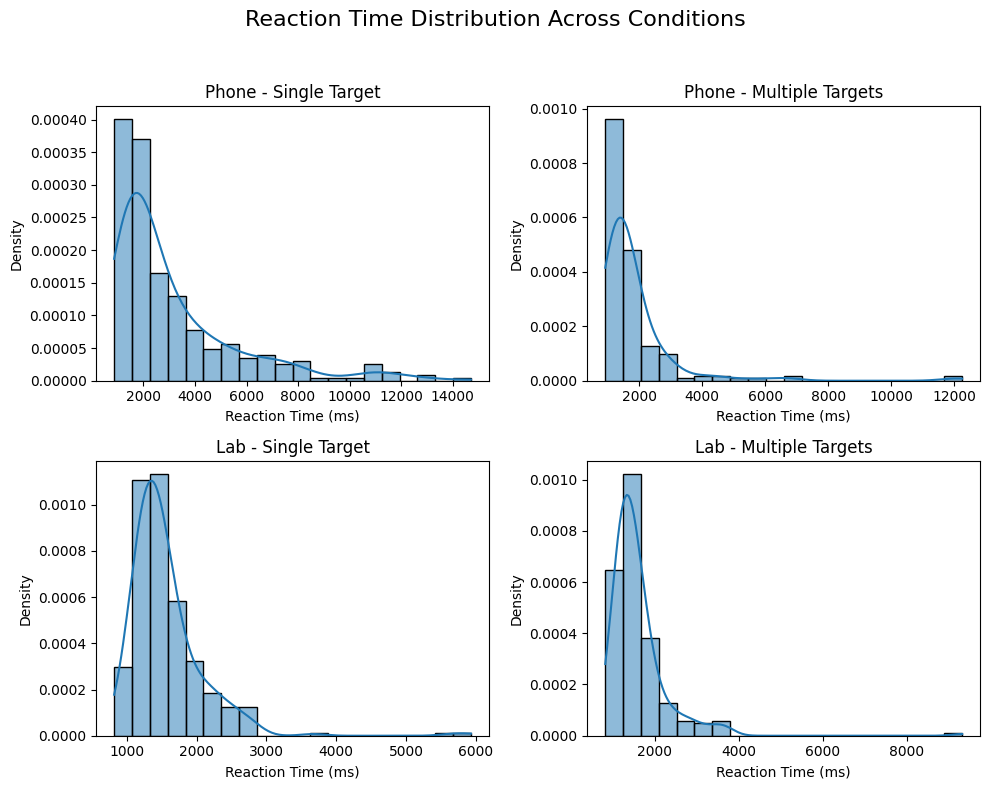

In [50]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Load datasets
# phn_single = pd.read_csv("single_phone_combined.csv")
# phn_multiple = pd.read_csv("multiple_phone_combined.csv")
# lab_single = pd.read_csv("single_lab_combined.csv")
# lab_multiple = pd.read_csv("multiple_lab_combined.csv")

# # Convert lab RT from seconds to milliseconds
# lab_single["Initial_RT"] = lab_single["Initial_RT"] * 1000
# lab_multiple["Initial_RT"] = lab_multiple["Initial_RT"] * 1000

# # Clean RT values
# rt_phn_single = phn_single["InitialResponseTime(ms)"].dropna()
# rt_phn_single = rt_phn_single[rt_phn_single > 0]

# rt_phn_multiple = phn_multiple["InitialResponseTime(ms)"].dropna()
# rt_phn_multiple = rt_phn_multiple[rt_phn_multiple > 0]

# rt_lab_single = lab_single["Initial_RT"].dropna()
# rt_lab_single = rt_lab_single[rt_lab_single > 0]

# rt_lab_multiple = lab_multiple["Initial_RT"].dropna()
# rt_lab_multiple = rt_lab_multiple[rt_lab_multiple > 0]

# # Create 4 density plots
# fig, axes = plt.subplots(2, 2, figsize=(10,8))

# sns.kdeplot(rt_phn_single, fill=True, ax=axes[0,0])
# axes[0,0].set_title("Phone - Single Target")

# sns.kdeplot(rt_phn_multiple, fill=True, ax=axes[0,1])
# axes[0,1].set_title("Phone - Multiple Targets")

# sns.kdeplot(rt_lab_single, fill=True, ax=axes[1,0])
# axes[1,0].set_title("Lab - Single Target")

# sns.kdeplot(rt_lab_multiple, fill=True, ax=axes[1,1])
# axes[1,1].set_title("Lab - Multiple Targets")

# for ax in axes.flat:
#     ax.set_xlabel("Reaction Time (ms)")
#     ax.set_ylabel("Density")

# plt.suptitle("Reaction time (ms) vs Density")
# plt.tight_layout()
# plt.show()
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
phn_single = pd.read_csv("single_phone_combined.csv")
phn_multiple = pd.read_csv("multiple_phone_combined.csv")
lab_single = pd.read_csv("single_lab_combined.csv")
lab_multiple = pd.read_csv("multiple_lab_combined.csv")

# Convert lab RT from seconds to milliseconds
lab_single["Initial_RT"] = lab_single["Initial_RT"] * 1000
lab_multiple["Initial_RT"] = lab_multiple["Initial_RT"] * 1000

# Clean RT values
rt_phn_single = phn_single["InitialResponseTime(ms)"].dropna()
rt_phn_single = rt_phn_single[rt_phn_single > 0]

rt_phn_multiple = phn_multiple["InitialResponseTime(ms)"].dropna()
rt_phn_multiple = rt_phn_multiple[rt_phn_multiple > 0]

rt_lab_single = lab_single["Initial_RT"].dropna()
rt_lab_single = rt_lab_single[rt_lab_single > 0]

rt_lab_multiple = lab_multiple["Initial_RT"].dropna()
rt_lab_multiple = rt_lab_multiple[rt_lab_multiple > 0]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(10,8))

sns.histplot(rt_phn_single, kde=True, stat="density", bins=20, ax=axes[0,0])
axes[0,0].set_title("Phone - Single Target")

sns.histplot(rt_phn_multiple, kde=True, stat="density", bins=20, ax=axes[0,1])
axes[0,1].set_title("Phone - Multiple Targets")

sns.histplot(rt_lab_single, kde=True, stat="density", bins=20, ax=axes[1,0])
axes[1,0].set_title("Lab - Single Target")

sns.histplot(rt_lab_multiple, kde=True, stat="density", bins=20, ax=axes[1,1])
axes[1,1].set_title("Lab - Multiple Targets")

for ax in axes.flat:
    ax.set_xlabel("Reaction Time (ms)")
    ax.set_ylabel("Density")

plt.suptitle("Reaction Time Distribution Across Conditions", fontsize=16)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

Overall, all conditions show positively skewed distributions, where most reaction times are concentrated at lower values while a smaller number of trials extend toward much higher reaction times. This indicates that participants generally responded quickly, but occasionally produced much slower responses.

In the Phone–Single Target condition, reaction times are widely spread with a long right tail extending to very high values. This suggests higher variability and the presence of several slow responses.

The Phone–Multiple Targets condition shows an even stronger right skew. Most responses occur at relatively lower reaction times, but there are some extremely large values, indicating that the presence of multiple targets on the phone may increase task difficulty and lead to occasional delays in response.

In contrast, the Lab–Single Target condition shows a more concentrated distribution with reaction times clustered within a narrower range. This suggests more consistent performance in the lab environment with fewer extreme slow responses.

Similarly, the Lab–Multiple Targets condition displays a right-skewed distribution but with less variability compared to the phone conditions. Although some slower responses are present, the majority of reaction times remain within a relatively smaller range.

Overall, the histograms suggest that reaction times in the phone conditions are more variable and include more extreme values, whereas lab conditions produce more consistent reaction times. Additionally, multiple-target tasks tend to produce slightly longer and more variable reaction times compared to single-target tasks, likely due to increased cognitive demand.

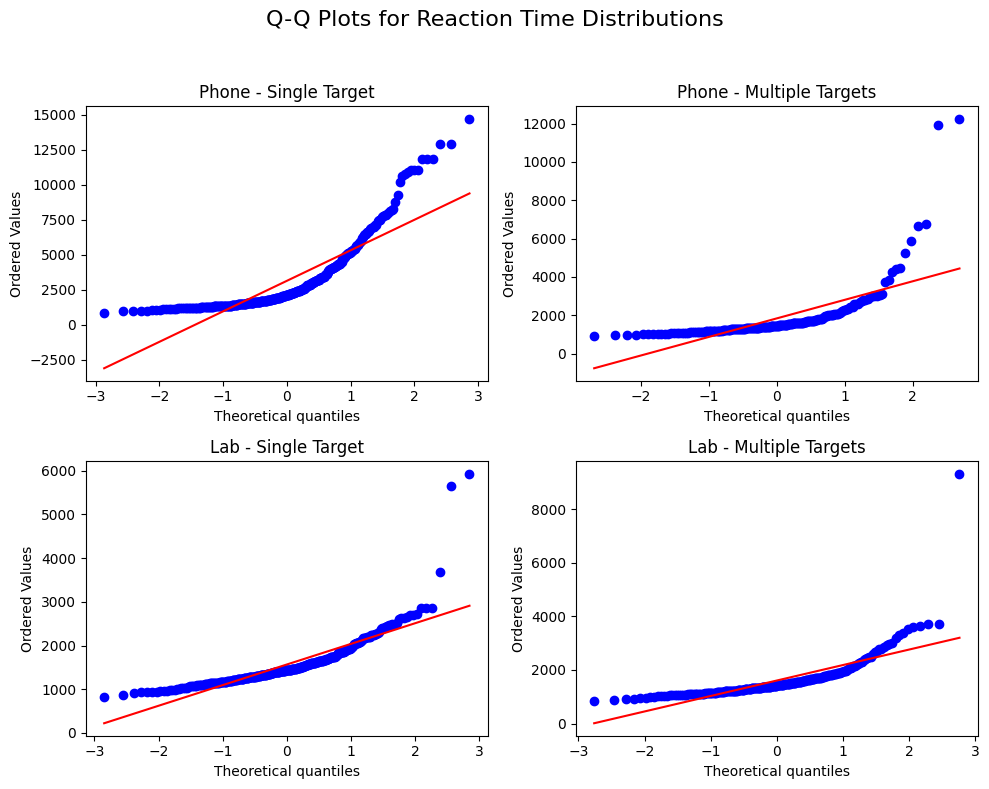

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load datasets
phn_single = pd.read_csv("single_phone_combined.csv")
phn_multiple = pd.read_csv("multiple_phone_combined.csv")
lab_single = pd.read_csv("single_lab_combined.csv")
lab_multiple = pd.read_csv("multiple_lab_combined.csv")

# Convert lab RT from seconds to ms
lab_single["Initial_RT"] = lab_single["Initial_RT"] * 1000
lab_multiple["Initial_RT"] = lab_multiple["Initial_RT"] * 1000

# Clean RT values
rt_phn_single = phn_single["InitialResponseTime(ms)"].dropna()
rt_phn_single = rt_phn_single[rt_phn_single > 0]

rt_phn_multiple = phn_multiple["InitialResponseTime(ms)"].dropna()
rt_phn_multiple = rt_phn_multiple[rt_phn_multiple > 0]

rt_lab_single = lab_single["Initial_RT"].dropna()
rt_lab_single = rt_lab_single[rt_lab_single > 0]

rt_lab_multiple = lab_multiple["Initial_RT"].dropna()
rt_lab_multiple = rt_lab_multiple[rt_lab_multiple > 0]

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(10,8))
plt.suptitle("Q-Q Plots for Reaction Time Distributions", fontsize=16)

# Phone Single
stats.probplot(rt_phn_single, dist="norm", plot=axes[0,0])
axes[0,0].set_title("Phone - Single Target")

# Phone Multiple
stats.probplot(rt_phn_multiple, dist="norm", plot=axes[0,1])
axes[0,1].set_title("Phone - Multiple Targets")

# Lab Single
stats.probplot(rt_lab_single, dist="norm", plot=axes[1,0])
axes[1,0].set_title("Lab - Single Target")

# Lab Multiple
stats.probplot(rt_lab_multiple, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Lab - Multiple Targets")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

These are Q–Q plots comparing your reaction time (RT) distributions to a normal distribution. If the data were normally distributed, the points would lie close to the red straight line. Deviations from this line indicate non-normality.

1. Phone – Single Target

Observation

Points strongly curve upward on the right side.

Several very large values (extreme points) appear at high quantiles.

Inference

The distribution is positively skewed (right-skewed).

There are very slow responses (outliers).

Reaction times vary widely when participants use the phone for a single target.

Meaning
Some participants responded much slower than average, creating a long right tail.

2. Phone – Multiple Targets

Observation

Similar rightward curvature, but more extreme points than the previous plot.

The tail is even longer.

Inference

Reaction times are strongly right-skewed.

Multiple-target phone tasks increase variability.

Participants occasionally take very long times to respond.

Meaning
Cognitive load may be higher when multiple targets are present on the phone, producing slower reactions.


3. Lab – Single Target

Observation

Points are closer to the line in the middle region.

Only a few outliers on the right side.

Inference

Distribution is closer to normal compared to phone data.

Reaction times are more consistent in the lab setting.

Fewer extreme slow responses.

Meaning
The controlled lab environment produces more stable reaction times.


4. Lab – Multiple Targets

Observation

Moderate upward deviation on the right side.

One very large outlier at the extreme end.

Inference

Still right-skewed, but less extreme than phone multiple targets.

Mostly consistent responses with few slow trials.

Meaning
Even with multiple targets, the lab condition maintains relatively stable performance.

![Alt text](SingleVsMultiple_Avg_RT.jpeg)

The boxplots compare average interaction reaction time for single-target and multiple-target tasks in phone and lab conditions.

In the phone condition, the single-target task shows a much higher median reaction time and greater variability than the multiple-target task, with several high outliers. This indicates that responses were slower and more inconsistent for the single-target task on the phone.

In the lab condition, the difference between single and multiple targets is smaller, and reaction times are more consistent overall.

Overall, reaction times are higher and more variable in the phone condition, while the lab condition shows more stable performance.

![AltText](SingleVsmultiple_Initial_Reaction_Time.jpeg)

In the phone condition, the single-target task has higher initial reaction times than the multiple-target task, and it also shows greater variability and several high outliers.

In the lab condition, single and multiple targets have similar reaction times, with much less variability compared to the phone condition.

![Alt text](initial_rt_heatmap.jpeg)

Single-target (Phone) shows much higher and more variable reaction times across players and levels. Several cells have extremely large values, indicating slow responses or possible outliers.

Multiple-target (Phone) shows lower and more consistent reaction times overall, with most values clustered in a smaller range and only a few spikes.

Reaction time tends to increase in later levels for some players in the single-target condition, suggesting possible fatigue or increased task difficulty.

The variability across players indicates individual differences in response speed.

Overall: The heatmaps suggest that single-target tasks on the phone produce slower and more inconsistent reaction times, whereas multiple-target tasks are generally faster and more stable across participants and levels.

![Alt text](Successful_rt_heatmap.jpeg)

Inference from the Successful Attempt Reaction Time Heatmaps

In the Single-target (Phone) condition, reaction times vary widely across players and levels. Several cells show very high values, indicating that even in successful attempts some players took much longer to respond, suggesting higher difficulty or inconsistent performance.

In the Multiple-target (Phone) condition, reaction times are generally lower and more clustered around similar values. Only a few cells show spikes, meaning most players responded within a similar time range.

The single-target heatmap shows greater variability and more extreme reaction times, while the multiple-target heatmap appears more uniform and stable.

Overall: Successful attempts in the single-target phone condition show slower and more variable reaction times, whereas the multiple-target condition demonstrates faster and more consistent responses across players and levels.

![alt text](FalseAlarmsAcrossLevels.jpeg)

The multiple-target condition generally shows a higher false alarm rate across several levels compared to the single-target condition.

There are noticeable spikes in false alarms at certain levels (e.g., around levels 6–7 and 10) in the multiple-target task.

The single-target condition mostly has low or zero false alarms, with a few spikes (notably around levels 4, 11, and 13).

The pattern suggests that as task complexity increases (multiple targets), participants are more likely to make false responses.

Overall: The multiple-target task leads to more frequent false alarms, indicating greater difficulty or higher cognitive load compared to the single-target condition.